In [2]:
!pip install pycocotools


  Obtaining dependency information for pycocotools from https://files.pythonhosted.org/packages/6b/56/9eedccfd1cfdaf6553d527bed0b2b5572550567a5786a8beb098027a3e5e/pycocotools-2.0.8-cp311-cp311-macosx_10_9_universal2.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.9/162.9 kB 5.1 MB/s eta 0:00:00


In [6]:
import torch
from torchvision import transforms
from pycocotools.coco import COCO
import os, cv2
import numpy as np

class CocoSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, ann_path, transforms=None):
        self.coco = COCO(ann_path)
        self.img_dir = img_dir
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.transforms = transforms

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        path = img_info['file_name']
        img = cv2.imread(os.path.join(self.img_dir, path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        mask = np.zeros(img.shape[:2], dtype=np.uint8)
        for ann in anns:
            rle = self.coco.annToMask(ann)
            mask = np.maximum(mask, rle * ann['category_id'])

        if self.transforms:
            img = self.transforms(img)
        mask = cv2.resize(mask, (512, 512), interpolation=cv2.INTER_NEAREST)
        return img, torch.tensor(mask, dtype=torch.long)


    def __len__(self):
        return len(self.ids)


loading annotations into memory...
Done (t=1.61s)
creating index...
index created!


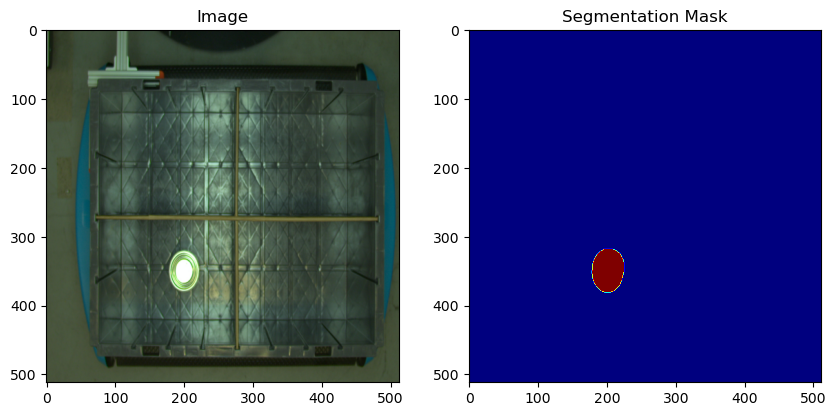

In [7]:
import matplotlib.pyplot as plt
import random
from torchvision import transforms

img_dir = "same-object-images"
ann_path = "same-object-coco.json"

transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

dataset = CocoSegmentationDataset(img_dir, ann_path, transforms=transforms)

sample_idx = random.randint(0, len(dataset)-1)
img, mask = dataset[sample_idx]

img_np = img.permute(1, 2, 0).numpy()
img_np = (img_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]  # unnormalize
img_np = (img_np * 255).astype('uint8')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title("Image")

plt.subplot(1, 2, 2)
plt.imshow(mask.numpy(), cmap='jet')
plt.title("Segmentation Mask")
plt.show()
